### PSD Pipeline
#### Table of Contents:
* [1. Environment Setup](#1-environment-setup)
    * [1.1 Library Imports](#11-library-imports)
    * [1.2 Dataset loading/inspection](#12-dataset-loadinginspection)
* [2. Data Segmentation](#data-segmentation)
* [3. Feature Extraction and Class Distribution](#3-feature-extraction--class-distribution)
    * [3.1 DWT](#31-dwt-feature-extraction)
    * [3.2 Class Distribution](#32-class-distribution)
* [4. Classification Schemes](#4-classification-schemes)
    * [4.1 Emotional vs. Neutral](#41-emotional-vs-neutral-remap--class-distribution)
    * [4.2 Positive vs. Negative](#42-positive-vs-negative-remap--class-distribution)
* [5. Model Training](#5-model-training)
    * [5.1 XGBoost](#51-xgboost)
        * [Emotional vs. Neutral](#511-emotional-vs-neutral)




### 1. Environment Setup

##### 1.1 Library Imports

In [ ]:
from pathlib import Path

import numpy as np
from scipy.io import loadmat
import pywt as pwt
from pywt import wavedec

import matplotlib.pyplot as plt
import seaborn as sns

import optuna
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import LeaveOneGroupOut, StratifiedKFold, StratifiedGroupKFold
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, roc_auc_score, balanced_accuracy_score, classification_report


/Users/connor/miniconda3/envs/ml/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


##### 1.2 Dataset loading/inspection

In [2]:
dataset_path = Path('DEED')
eeg_dataset = []
subject_ids = []

for file in dataset_path.iterdir():
    mat = loadmat(file)
    eeg = mat['Data']
    fname = file.stem  
    label_part = [part for part in fname.split("_") if part.startswith("E")][0]
    subject_part = [part for part in fname.split("_") if part.startswith("S")][0]
    label = int(label_part[1:])  
    subject_id = subject_part[1:-1]  # last two digits = subject number
    
    eeg_dataset.append((eeg, label))
    subject_ids.append(subject_id)

print(f"Loaded {len(eeg_dataset)} trials.")
print(f"Unique subjects: {len(set(subject_ids))}")
print(f"Subject IDs: {sorted(set(subject_ids))}")
print("Example shapes:", [(arr.shape, lbl) for arr, lbl in eeg_dataset[:3]])

print("\nSample filename → label mapping:")
for file, (_, label) in zip(dataset_path.iterdir(), eeg_dataset[:10]):
    print(f"  {file.stem} → E{label}")

Loaded 533 trials.
Unique subjects: 34
Subject IDs: ['002', '003', '004', '005', '007', '011', '012', '013', '014', '015', '016', '017', '018', '020', '021', '022', '023', '024', '025', '027', '028', '029', '030', '031', '032', '033', '034', '035', '036', '037', '038', '039', '040', '042']
Example shapes: [((6, 290000), 2), ((6, 36000), 2), ((6, 51000), 3)]

Sample filename → label mapping:
  G_S0321_M1_E2_R1_N2_raw_ref → E2
  G_S0213_M3_E2_R7_N2_raw_ref → E2
  G_S0393_M2_E3_R5_REM_raw_ref → E3
  G_S0243_M3_E2_R2_N2_raw_ref → E2
  G_S0311_M3_E5_R2_N2_raw_ref → E5
  G_S0031_M1_E3_R4_nan_raw_ref → E3
  G_S0043_M2_E2_R5_N2_raw_ref → E2
  G_S0072_M1_E0_R11_N1_raw_ref → E0
  G_S0242_M1_E3_R3_W_raw_ref → E3
  G_S0342_M2_E3_R3_N2_raw_ref → E3


### 2. Data Segmentation

Done into 20s windows.

In [3]:
def segmentation(eeg_dataset, subject_ids, window_sec, fs):
    window_size = int(window_sec * fs)
    X = []
    y = []
    groups = []

    for (eeg_array, label), sid in zip(eeg_dataset, subject_ids):
        n_samples = eeg_array.shape[1]
        start = 0
        while start + window_size <= n_samples:
            window = eeg_array[:, start:start + window_size]
            X.append(window)
            y.append(label)
            groups.append(sid)
            start += window_size  

    return X, y, groups

windows, window_labels, window_groups = segmentation(eeg_dataset, subject_ids, 20, 200)
print(f"Total 20 second windows: {len(windows)}")
print(f"Unique subjects: {len(set(window_groups))}")

Total 20 second windows: 7490
Unique subjects: 34


### 3. Feature Extraction & Class Distribution

DWT features are extracted from each 20s window decomposed to level 5. For each channel, energy, variance, standard deviation, and peak amplitude are computed across all coefficient arrays, alongside hemispheric asymmetry features for each frontal, frontotemporal, and temporal channel pair, yielding 198 features per window.

##### 3.1 DWT Feature Extraction

In [4]:
CHANNELS = ['F3', 'F4', 'FT7', 'FT8', 'T7', 'T8']
ASYM_PAIRS = [(0, 1), (2, 3), (4, 5)]  # F3/F4, FT7/FT8, T7/T8

def extract_dwt_features(segmented_windows, labels):
    features = []
    for window in segmented_windows:
        channel_features = []
        channel_coeffs = []

        # Per-channel per-band stats
        for ch in range(window.shape[0]):
            coeffs = wavedec(window[ch], 'db4', level=5)
            channel_coeffs.append(coeffs)
            for coeff in coeffs:
                channel_features.extend([
                    np.mean(coeff),
                    np.std(coeff),
                    np.var(coeff),
                    np.sum(coeff**2),        # band energy
                    np.max(np.abs(coeff)),   # peak amplitude
                ])

        for left, right in ASYM_PAIRS:
            for level in range(6):  # 6 coefficient arrays at level=5
                left_energy = np.sum(channel_coeffs[left][level]**2)
                right_energy = np.sum(channel_coeffs[right][level]**2)
                asymmetry = (left_energy - right_energy) / (left_energy + right_energy + 1e-8)
                channel_features.append(asymmetry)

        features.append(channel_features)

    X = np.array(features)
    y = np.array(labels)
    return X, y


##### 3.2 Class Distribution

In [5]:
X, y = extract_dwt_features(windows, window_labels)
print(X.shape)
print(y.shape) 

print("\n=== Total Class Distribution===")
unique, counts = np.unique(y, return_counts=True)
for label, count in zip(unique, counts):
    print(f"E{label}: {count} windows ({count/len(y)*100:.1f}%)")

(7490, 198)
(7490,)

=== Total Class Distribution===
E0: 1294 windows (17.3%)
E1: 305 windows (4.1%)
E2: 1069 windows (14.3%)
E3: 2855 windows (38.1%)
E4: 1698 windows (22.7%)
E5: 269 windows (3.6%)


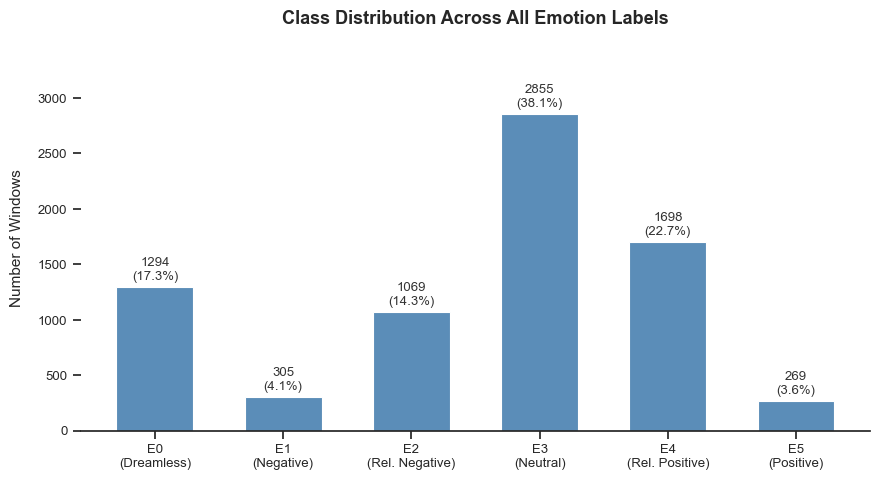

In [6]:
unique, counts = np.unique(y, return_counts=True)
total = len(y)

classes = ['E0\n(Dreamless)', 'E1\n(Negative)', 'E2\n(Rel. Negative)',
           'E3\n(Neutral)', 'E4\n(Rel. Positive)', 'E5\n(Positive)']

sns.set_theme(style="ticks", font_scale=1.1)
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(classes, counts, color='#5b8db8', edgecolor='white', linewidth=0.8, width=0.6)

for bar, count in zip(bars, counts):
    pct = count / total * 100
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 40,
            f'{count}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=9.5, color='#333333')

ax.set_ylabel('Number of Windows', fontsize=11, labelpad=10)
ax.set_title('Class Distribution Across All Emotion Labels', fontsize=13, fontweight='bold', pad=15)
ax.set_ylim(0, max(counts) * 1.22)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.tick_params(axis='x', labelsize=9.5)
ax.tick_params(axis='y', labelsize=9.5)

plt.tight_layout()
plt.savefig('class_dist_full.png', dpi=300, bbox_inches='tight')
plt.show()

### 4. Classification Schemes

##### 4.1 Emotional vs. Neutral (remap + class distribution)  
Emotional {E1, E2, E4, E5} vs. Neutral Dream {E3} 

In [7]:
def remap_emotional_neutral(y):
    y = np.array(y)
    keep_mask = np.isin(y, [1, 2, 3, 4, 5])  
    new_y = np.zeros(len(y), dtype=int)
    new_y[np.isin(y, [1, 2, 4, 5])] = 1  
    return new_y[keep_mask], keep_mask

y_en, mask_en = remap_emotional_neutral(y)
X_en = X[mask_en]
groups_en = np.array(window_groups)[mask_en]

print(f"\n=== Emotional vs. Neutral Class Distribution ===")
print(f"  Total: {len(y_en)}")
print(f"  Neutral (0): {np.sum(y_en == 0)} ({np.sum(y_en == 0)/len(y_en)*100:.1f}%)")
print(f"  Emotional (1): {np.sum(y_en == 1)} ({np.sum(y_en == 1)/len(y_en)*100:.1f}%)")


=== Emotional vs. Neutral Class Distribution ===
  Total: 6196
  Neutral (0): 2855 (46.1%)
  Emotional (1): 3341 (53.9%)


In [8]:
# Subject Wise Class Distribution (EN)
print("=== Subject Wise Class Distribution (EN) ===")
for subject in sorted(set(groups_en)):
    mask = groups_en == subject
    labels = y_en[mask]
    unique = np.unique(labels)
    print(f"Subject {subject}: {len(labels)} windows, classes: {unique}, counts: {np.bincount(labels)}")

=== Subject Wise Class Distribution (EN) ===
Subject 002: 185 windows, classes: [0 1], counts: [ 18 167]
Subject 003: 400 windows, classes: [0 1], counts: [188 212]
Subject 004: 245 windows, classes: [0 1], counts: [104 141]
Subject 005: 242 windows, classes: [0 1], counts: [155  87]
Subject 007: 511 windows, classes: [0 1], counts: [ 78 433]
Subject 011: 43 windows, classes: [0], counts: [43]
Subject 012: 95 windows, classes: [0 1], counts: [83 12]
Subject 013: 26 windows, classes: [0 1], counts: [12 14]
Subject 014: 56 windows, classes: [0], counts: [56]
Subject 015: 269 windows, classes: [0 1], counts: [122 147]
Subject 016: 213 windows, classes: [0 1], counts: [184  29]
Subject 017: 213 windows, classes: [0 1], counts: [177  36]
Subject 018: 7 windows, classes: [0], counts: [7]
Subject 020: 105 windows, classes: [0 1], counts: [95 10]
Subject 021: 375 windows, classes: [0 1], counts: [162 213]
Subject 022: 207 windows, classes: [0 1], counts: [112  95]
Subject 023: 173 windows, cla

##### 4.2 Positive vs. Negative (remap + class distribution)
Positive {E4, E5} vs. Negative {E1, E2}

In [9]:
def remap_positive_negative(y):
    y = np.array(y)
    keep_mask = np.isin(y, [1, 2, 4, 5])  
    new_y = np.zeros(len(y), dtype=int)
    new_y[np.isin(y, [4, 5])] = 1  
    return new_y[keep_mask], keep_mask

y_pn, mask_pn = remap_positive_negative(y)
X_pn = X[mask_pn]
groups_pn = np.array(window_groups)[mask_pn]

print(f"\n=== Positive vs. Negative Class Distribution ===")
print(f"  Total: {len(y_pn)}")
print(f"  Negative (0): {np.sum(y_pn == 0)} ({np.sum(y_pn == 0)/len(y_pn)*100:.1f}%)")
print(f"  Positive (1): {np.sum(y_pn == 1)} ({np.sum(y_pn == 1)/len(y_pn)*100:.1f}%)")


=== Positive vs. Negative Class Distribution ===
  Total: 3341
  Negative (0): 1374 (41.1%)
  Positive (1): 1967 (58.9%)


In [10]:
# Subject Wise Class Distribution (PN)
print("=== Subject Wise Class Distribution (PN) ===")
for subject in sorted(set(groups_pn)):
    mask = groups_pn == subject
    labels = y_pn[mask]
    unique = np.unique(labels)
    print(f"Subject {subject}: {len(labels)} windows, classes: {unique}, counts: {np.bincount(labels)}")

=== Subject Wise Class Distribution (PN) ===
Subject 002: 167 windows, classes: [0 1], counts: [89 78]
Subject 003: 212 windows, classes: [0 1], counts: [ 65 147]
Subject 004: 141 windows, classes: [0 1], counts: [68 73]
Subject 005: 87 windows, classes: [0 1], counts: [33 54]
Subject 007: 433 windows, classes: [0 1], counts: [206 227]
Subject 012: 12 windows, classes: [0], counts: [12]
Subject 013: 14 windows, classes: [1], counts: [ 0 14]
Subject 015: 147 windows, classes: [0 1], counts: [ 22 125]
Subject 016: 29 windows, classes: [1], counts: [ 0 29]
Subject 017: 36 windows, classes: [0 1], counts: [28  8]
Subject 020: 10 windows, classes: [0], counts: [10]
Subject 021: 213 windows, classes: [0 1], counts: [ 28 185]
Subject 022: 95 windows, classes: [0 1], counts: [46 49]
Subject 023: 100 windows, classes: [0 1], counts: [21 79]
Subject 024: 235 windows, classes: [0 1], counts: [139  96]
Subject 025: 34 windows, classes: [1], counts: [ 0 34]
Subject 027: 26 windows, classes: [0 1], 

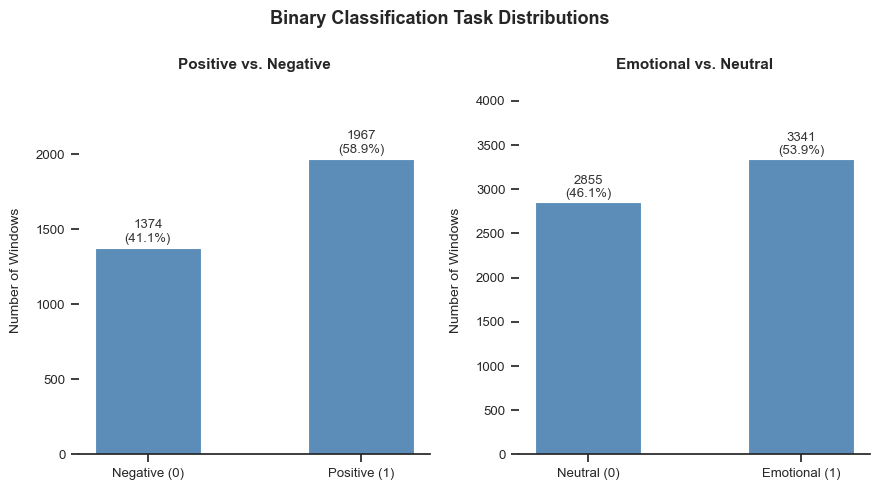

In [11]:
sns.set_theme(style="ticks", font_scale=1.1)
fig, (ax2, ax3) = plt.subplots(1, 2, figsize=(9, 5))

# Positive vs Negative
pn_counts = [np.sum(y_pn == 0), np.sum(y_pn == 1)]
pn_labels = ['Negative (0)', 'Positive (1)']
bars2 = ax2.bar(pn_labels, pn_counts, color='#5b8db8', edgecolor='white', linewidth=0.8, width=0.5)
for bar, count in zip(bars2, pn_counts):
    pct = count / sum(pn_counts) * 100
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 20,
             f'{count}\n({pct:.1f}%)',
             ha='center', va='bottom', fontsize=9.5, color='#333333')
ax2.set_title('Positive vs. Negative', fontsize=11, fontweight='bold', pad=12)
ax2.set_ylabel('Number of Windows', fontsize=10, labelpad=10)
ax2.set_ylim(0, max(pn_counts) * 1.25)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.tick_params(axis='x', labelsize=9.5)
ax2.tick_params(axis='y', labelsize=9.5)

# Emotional vs Neutral
en_counts = [np.sum(y_en == 0), np.sum(y_en == 1)]
en_labels = ['Neutral (0)', 'Emotional (1)']
bars3 = ax3.bar(en_labels, en_counts, color='#5b8db8', edgecolor='white', linewidth=0.8, width=0.5)
for bar, count in zip(bars3, en_counts):
    pct = count / sum(en_counts) * 100
    ax3.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 20,
             f'{count}\n({pct:.1f}%)',
             ha='center', va='bottom', fontsize=9.5, color='#333333')
ax3.set_title('Emotional vs. Neutral', fontsize=11, fontweight='bold', pad=12)
ax3.set_ylabel('Number of Windows', fontsize=10, labelpad=10)
ax3.set_ylim(0, max(en_counts) * 1.25)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['left'].set_visible(False)
ax3.tick_params(axis='x', labelsize=9.5)
ax3.tick_params(axis='y', labelsize=9.5)

fig.suptitle('Binary Classification Task Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('class_dist_binary.png', dpi=300, bbox_inches='tight')
plt.show()

### 5. Model Training
Hyperparameters are optimized using Optuna with 5-fold StratifiedGroupKFold for LOSO and 5-fold StratifiedKFold for 10F CV

#### 5.1 XGBoost

##### General Functions for Training

In [12]:
optuna.logging.set_verbosity(optuna.logging.INFO)

def xgb_hyperparameter_training_loso(X, y, groups, model_name, classification_scheme):
    print(f"=== Hyperparameter Tuning - {model_name} ({classification_scheme}) ===")

    def objective(trial):
        params = {
            'n_estimators':     trial.suggest_int('n_estimators', 100, 600),
            'max_depth':        trial.suggest_int('max_depth', 3, 8),
            'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'gamma':            trial.suggest_float('gamma', 0, 5),
            'eval_metric':      'logloss',
        }
        cv = StratifiedGroupKFold(n_splits=5)
        scores = []
        for train_idx, val_idx in cv.split(X, y, groups):
            X_train, X_val = X[train_idx], X[val_idx]
            y_train, y_val = y[train_idx], y[val_idx]

            neg = np.sum(y_train == 0)
            pos = np.sum(y_train == 1)
            params['scale_pos_weight'] = neg/pos

            model = XGBClassifier(**params, n_jobs=-1, random_state = 42)
            model.fit(X_train, y_train)
            preds = model.predict(X_val)

            scores.append(f1_score(y_val, preds, average='macro'))

        return np.mean(scores)

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials = 50)
    print(f"Best params: {study.best_params}")
    print(f"Best CV F1: {study.best_value:.4f}")


    # Save best params
    best_params = study.best_params
    best_params['random_state'] = 42
    best_params['n_jobs'] = -1
    return best_params

In [18]:
optuna.logging.set_verbosity(optuna.logging.INFO)

def xgb_hyperparameter_training_10f(X, y,model_name, classification_scheme):
    print(f"=== Hyperparameter Tuning - {model_name} ({classification_scheme}) ===")

    def objective(trial):
        params = {
            'n_estimators':     trial.suggest_int('n_estimators', 100, 600),
            'max_depth':        trial.suggest_int('max_depth', 3, 8),
            'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'gamma':            trial.suggest_float('gamma', 0, 5),
            'eval_metric':      'logloss',
        }
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        scores = []
        for train_idx, val_idx in cv.split(X, y):
            X_train, X_val = X[train_idx], X[val_idx]
            y_train, y_val = y[train_idx], y[val_idx]

            neg = np.sum(y_train == 0)
            pos = np.sum(y_train == 1)
            params['scale_pos_weight'] = neg/pos

            model = XGBClassifier(**params, n_jobs=-1, random_state = 42)
            model.fit(X_train, y_train)
            preds = model.predict(X_val)

            scores.append(f1_score(y_val, preds, average='macro'))

        return np.mean(scores)

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials = 50)
    print(f"Best params: {study.best_params}")
    print(f"Best CV F1: {study.best_value:.4f}")


    # Save best params
    best_params = study.best_params
    best_params['random_state'] = 42
    best_params['n_jobs'] = -1
    return best_params

In [19]:
def xgb_loso_loop(X, y, groups, params, model_name, classification_scheme):
    # LOSO evaluation with fixed params
    print(f"\n=== LOSO - {model_name} ({classification_scheme}) ===")
    logo = LeaveOneGroupOut()
    accs = []
    f1s = []
    aurocs = []
    bal_accs = []

    for fold, (train_idx, test_idx) in enumerate(logo.split(X, y, groups)):
        if len(np.unique(y[test_idx])) < 2:
            continue

        subject = groups[test_idx[0]]
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        #Per fold class weighting
        neg = np.sum(y_train == 0)
        pos = np.sum(y_train == 1)

        fold_params = params.copy()
        fold_params['scale_pos_weight'] = neg/pos

        model = XGBClassifier(**fold_params)
        model.fit(X_train, y_train)

        preds = model.predict(X_test)
        proba = model.predict_proba(X_test)[:, 1]

        accs.append(accuracy_score(y_test, preds))
        f1s.append(f1_score(y_test, preds, average='macro'))
        aurocs.append(roc_auc_score(y_test, proba))
        bal_accs.append(balanced_accuracy_score(y_test, preds))
        print(f"Subject {subject} | Balanced Accuracy: {bal_accs[-1]:.4f} | Accuracy: {accs[-1]:.4f} | F1: {f1s[-1]:.4f} | AUROC: {aurocs[-1]:.4f}")

    print(f"Balanced Accuracy:  {np.mean(bal_accs):.4f} ± {np.std(bal_accs):.4f}")
    print(f"Accuracy:  {np.mean(accs):.4f} ± {np.std(accs):.4f}")
    print(f"F1:  {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")
    print(f"AUROC:  {np.mean(aurocs):.4f} ± {np.std(aurocs):.4f}")


In [20]:
def xgb_ten_fold_cv_loop(X, y, params, model_name, classification_scheme):
    print(f"\n=== 10-Fold CV - {model_name} ({classification_scheme}) ===")
    # 10 Fold Cross CV with same tuned params
    cv_10fold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    accs = []
    f1s = []
    bal_accs = []
    aurocs = []

    for train_idx, test_idx in cv_10fold.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        neg = np.sum(y_train == 0)
        pos = np.sum(y_train == 1)
        fold_params = params.copy()
        fold_params['scale_pos_weight'] = neg / pos

        model = XGBClassifier(**fold_params)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        proba = model.predict_proba(X_test)[:, 1]

        accs.append(accuracy_score(y_test, preds))
        f1s.append(f1_score(y_test, preds, average='macro'))
        aurocs.append(roc_auc_score(y_test, proba))
        bal_accs.append(balanced_accuracy_score(y_test, preds))

    print(f"Accuracy:          {np.mean(accs):.4f} ± {np.std(accs):.4f}")
    print(f"F1:                {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")
    print(f"Balanced Accuracy: {np.mean(bal_accs):.4f} ± {np.std(bal_accs):.4f}")
    print(f"AUROC:             {np.mean(aurocs):.4f} ± {np.std(aurocs):.4f}")

##### 5.1.1 Emotional vs. Neutral

In [21]:
#Hyperparameter tuning for EN LOSO
xgb_en_params_loso = xgb_hyperparameter_training_loso(X_en, y_en, groups_en, "XGBoost", "Emotional vs. Neutral")

[I 2026-03-25 14:20:30,418] A new study created in memory with name: no-name-31f32fb6-703d-4da4-861d-029fd03d075f


=== Hyperparameter Tuning - XGBoost (Emotional vs. Neutral) ===


[I 2026-03-25 14:20:34,450] Trial 0 finished with value: 0.49619284452161316 and parameters: {'n_estimators': 208, 'max_depth': 4, 'learning_rate': 0.02583829611550894, 'subsample': 0.9319522430453333, 'colsample_bytree': 0.6831880909814025, 'min_child_weight': 2, 'gamma': 3.609926807120292}. Best is trial 0 with value: 0.49619284452161316.
[I 2026-03-25 14:20:50,596] Trial 1 finished with value: 0.5032756938976384 and parameters: {'n_estimators': 248, 'max_depth': 8, 'learning_rate': 0.016540441122723997, 'subsample': 0.8786267367853494, 'colsample_bytree': 0.664484047201883, 'min_child_weight': 6, 'gamma': 2.6219288913962107}. Best is trial 1 with value: 0.5032756938976384.
[I 2026-03-25 14:20:58,305] Trial 2 finished with value: 0.5014517483126101 and parameters: {'n_estimators': 536, 'max_depth': 3, 'learning_rate': 0.20442032819894876, 'subsample': 0.6122003642971243, 'colsample_bytree': 0.9763800781526867, 'min_child_weight': 2, 'gamma': 3.891896174661521}. Best is trial 1 with v

Best params: {'n_estimators': 577, 'max_depth': 6, 'learning_rate': 0.06992542673109924, 'subsample': 0.7587448870425082, 'colsample_bytree': 0.6028958885631277, 'min_child_weight': 7, 'gamma': 0.9409639183063616}
Best CV F1: 0.5272


In [23]:
xgb_en_params_10f = xgb_hyperparameter_training_10f(X_en, y_en, "XGBoost", "Emotional vs. Neutral")

[I 2026-03-25 14:33:53,328] A new study created in memory with name: no-name-eba51eea-d3e4-45f9-b759-3bcd0e549506


=== Hyperparameter Tuning - XGBoost (Emotional vs. Neutral) ===


[I 2026-03-25 14:34:23,124] Trial 0 finished with value: 0.7074308016195177 and parameters: {'n_estimators': 425, 'max_depth': 8, 'learning_rate': 0.023799287129254824, 'subsample': 0.8428179438767354, 'colsample_bytree': 0.7579438722383591, 'min_child_weight': 9, 'gamma': 0.5780982369462351}. Best is trial 0 with value: 0.7074308016195177.
[I 2026-03-25 14:34:26,448] Trial 1 finished with value: 0.6658896549063764 and parameters: {'n_estimators': 107, 'max_depth': 7, 'learning_rate': 0.25601393072123135, 'subsample': 0.8696908038321645, 'colsample_bytree': 0.9094236280570163, 'min_child_weight': 3, 'gamma': 4.4331228287255255}. Best is trial 0 with value: 0.7074308016195177.
[I 2026-03-25 14:34:33,355] Trial 2 finished with value: 0.6805747705811815 and parameters: {'n_estimators': 406, 'max_depth': 8, 'learning_rate': 0.15009103744266697, 'subsample': 0.7123440651753574, 'colsample_bytree': 0.9971084176191849, 'min_child_weight': 9, 'gamma': 4.630809495830951}. Best is trial 0 with v

Best params: {'n_estimators': 423, 'max_depth': 7, 'learning_rate': 0.02360579128820358, 'subsample': 0.9250775837874134, 'colsample_bytree': 0.7069759673084169, 'min_child_weight': 4, 'gamma': 1.5830197801702148}
Best CV F1: 0.7096


In [24]:
#LOSO Evaluation
xgb_en_loso = xgb_loso_loop(X_en, y_en, groups_en, xgb_en_params_loso, "XGBoost", "Emotional vs. Neutral")


=== LOSO - XGBoost (Emotional vs. Neutral) ===
Subject 002 | Balanced Accuracy: 0.5135 | Accuracy: 0.5243 | F1: 0.4182 | AUROC: 0.4910
Subject 003 | Balanced Accuracy: 0.4524 | Accuracy: 0.4425 | F1: 0.4318 | AUROC: 0.4726
Subject 004 | Balanced Accuracy: 0.4726 | Accuracy: 0.4612 | F1: 0.4612 | AUROC: 0.4511
Subject 005 | Balanced Accuracy: 0.5136 | Accuracy: 0.5579 | F1: 0.5136 | AUROC: 0.5319
Subject 007 | Balanced Accuracy: 0.5191 | Accuracy: 0.5323 | F1: 0.4535 | AUROC: 0.5152
Subject 012 | Balanced Accuracy: 0.6004 | Accuracy: 0.8000 | F1: 0.5899 | AUROC: 0.6807
Subject 013 | Balanced Accuracy: 0.6726 | Accuracy: 0.6538 | F1: 0.6406 | AUROC: 0.6607
Subject 015 | Balanced Accuracy: 0.4420 | Accuracy: 0.4275 | F1: 0.4198 | AUROC: 0.4202
Subject 016 | Balanced Accuracy: 0.5194 | Accuracy: 0.5962 | F1: 0.4730 | AUROC: 0.4803
Subject 017 | Balanced Accuracy: 0.5002 | Accuracy: 0.4085 | F1: 0.3857 | AUROC: 0.4933
Subject 020 | Balanced Accuracy: 0.4605 | Accuracy: 0.5905 | F1: 0.4277 

In [25]:
#10Fold CV
xgb_en_10f = xgb_ten_fold_cv_loop(X_en, y_en, xgb_en_params_10f, "XGBoost", "Emotional vs. Neutral")


=== 10-Fold CV - XGBoost (Emotional vs. Neutral) ===
Accuracy:          0.7140 ± 0.0113
F1:                0.7124 ± 0.0118
Balanced Accuracy: 0.7128 ± 0.0122
AUROC:             0.7855 ± 0.0086


##### 5.1.2 Positive vs. Negative

In [26]:
#Hyperparameter tuning
xgb_pn_params_loso = xgb_hyperparameter_training_loso(X_pn, y_pn, groups_pn, "XGBoost", "Positive vs. Negative")

[I 2026-03-25 14:51:46,329] A new study created in memory with name: no-name-49a50758-56b4-492e-8c01-f7c3d8bbfd34


=== Hyperparameter Tuning - XGBoost (Positive vs. Negative) ===


[I 2026-03-25 14:52:01,954] Trial 0 finished with value: 0.48082976790036636 and parameters: {'n_estimators': 479, 'max_depth': 6, 'learning_rate': 0.0421351111626862, 'subsample': 0.6713566101877807, 'colsample_bytree': 0.6722817544770885, 'min_child_weight': 3, 'gamma': 0.9268904189960331}. Best is trial 0 with value: 0.48082976790036636.
[I 2026-03-25 14:52:12,773] Trial 1 finished with value: 0.4882019744210993 and parameters: {'n_estimators': 458, 'max_depth': 5, 'learning_rate': 0.02119063782470212, 'subsample': 0.9444130236554336, 'colsample_bytree': 0.6717814983837394, 'min_child_weight': 9, 'gamma': 0.9239650307490727}. Best is trial 1 with value: 0.4882019744210993.
[I 2026-03-25 14:52:15,429] Trial 2 finished with value: 0.4862239016501893 and parameters: {'n_estimators': 356, 'max_depth': 3, 'learning_rate': 0.17946301658474303, 'subsample': 0.9074258911166573, 'colsample_bytree': 0.7868638032157393, 'min_child_weight': 9, 'gamma': 3.3480152567257795}. Best is trial 1 with 

Best params: {'n_estimators': 312, 'max_depth': 4, 'learning_rate': 0.11573596973166903, 'subsample': 0.7794183371076638, 'colsample_bytree': 0.7758926135736934, 'min_child_weight': 8, 'gamma': 3.579322281409602}
Best CV F1: 0.4907


In [28]:
xgb_pn_params_10f = xgb_hyperparameter_training_10f(X_pn, y_pn, "XGBoost", "Positive vs. Negative")

[I 2026-03-25 14:56:41,087] A new study created in memory with name: no-name-1b8906be-ca34-46bc-95fd-1c83e4cb0ed5


=== Hyperparameter Tuning - XGBoost (Positive vs. Negative) ===


[I 2026-03-25 14:56:44,351] Trial 0 finished with value: 0.6704924440210174 and parameters: {'n_estimators': 194, 'max_depth': 5, 'learning_rate': 0.024532812581015098, 'subsample': 0.792985323139189, 'colsample_bytree': 0.6470760312953755, 'min_child_weight': 4, 'gamma': 4.820569266379095}. Best is trial 0 with value: 0.6704924440210174.
[I 2026-03-25 14:56:54,432] Trial 1 finished with value: 0.6360404596691887 and parameters: {'n_estimators': 450, 'max_depth': 5, 'learning_rate': 0.2624376254706926, 'subsample': 0.780783644028153, 'colsample_bytree': 0.9855687875607714, 'min_child_weight': 10, 'gamma': 0.23028250075268153}. Best is trial 0 with value: 0.6704924440210174.
[I 2026-03-25 14:57:01,363] Trial 2 finished with value: 0.6495804714145758 and parameters: {'n_estimators': 271, 'max_depth': 6, 'learning_rate': 0.10357585177493434, 'subsample': 0.7421986042920963, 'colsample_bytree': 0.8908259687681399, 'min_child_weight': 10, 'gamma': 1.4787556709035754}. Best is trial 0 with v

Best params: {'n_estimators': 409, 'max_depth': 8, 'learning_rate': 0.019129374703205592, 'subsample': 0.8373327934433444, 'colsample_bytree': 0.6024999314559453, 'min_child_weight': 3, 'gamma': 3.9234394711637837}
Best CV F1: 0.6870


In [29]:
#LOSO Evaluation
xgb_pn_loso = xgb_loso_loop(X_pn, y_pn, groups_pn, xgb_pn_params_loso, "XGBoost", "Positive vs. Negative")


=== LOSO - XGBoost (Positive vs. Negative) ===
Subject 002 | Balanced Accuracy: 0.6031 | Accuracy: 0.6048 | F1: 0.6031 | AUROC: 0.6217
Subject 003 | Balanced Accuracy: 0.3200 | Accuracy: 0.3962 | F1: 0.3270 | AUROC: 0.2721
Subject 004 | Balanced Accuracy: 0.4753 | Accuracy: 0.4823 | F1: 0.4577 | AUROC: 0.5336
Subject 005 | Balanced Accuracy: 0.4293 | Accuracy: 0.4598 | F1: 0.4296 | AUROC: 0.3956
Subject 007 | Balanced Accuracy: 0.4986 | Accuracy: 0.5150 | F1: 0.4416 | AUROC: 0.4998
Subject 015 | Balanced Accuracy: 0.4000 | Accuracy: 0.6803 | F1: 0.4049 | AUROC: 0.1829
Subject 017 | Balanced Accuracy: 0.6696 | Accuracy: 0.5556 | F1: 0.5429 | AUROC: 0.7545
Subject 021 | Balanced Accuracy: 0.5136 | Accuracy: 0.7606 | F1: 0.5121 | AUROC: 0.5259
Subject 022 | Balanced Accuracy: 0.5200 | Accuracy: 0.5158 | F1: 0.5092 | AUROC: 0.5306
Subject 023 | Balanced Accuracy: 0.4180 | Accuracy: 0.5500 | F1: 0.4224 | AUROC: 0.3285
Subject 024 | Balanced Accuracy: 0.3644 | Accuracy: 0.3319 | F1: 0.3236 

In [30]:
#10Fold CV
xgb_pn_10f = xgb_ten_fold_cv_loop(X_pn, y_pn, xgb_pn_params_10f, "XGBoost", "Positive vs. Negative")


=== 10-Fold CV - XGBoost (Positive vs. Negative) ===
Accuracy:          0.7067 ± 0.0244
F1:                0.7015 ± 0.0263
Balanced Accuracy: 0.7063 ± 0.0284
AUROC:             0.7724 ± 0.0258


#### 5.2 KNN (K-Nearest Neighbors)

##### General Functions for Training

In [31]:
def subject_normalize(X, groups):
    X_norm = X.copy()
    for subj in np.unique(groups):
        mask = groups == subj
        scaler = StandardScaler()
        X_norm[mask] = scaler.fit_transform(X[mask])
    return X_norm

In [32]:
optuna.logging.set_verbosity(optuna.logging.INFO)

def knn_hyperparameter_training_loso(X, y, groups, model_name, classification_scheme):
    print(f"=== Hyperparameter Tuning - {model_name} ({classification_scheme}) ===")

    def objective(trial):
        params = {
            'n_neighbors': trial.suggest_int('n_neighbors', 1, 30),
            'weights': trial.suggest_categorical('weights', ['uniform', 'distance']),
            'metric': trial.suggest_categorical('metric', ['euclidean', 'manhattan', 'cosine']),
            'leaf_size': trial.suggest_int('leaf_size', 10, 50),
        }
        cv = StratifiedGroupKFold(n_splits=5)
        scores = []
        for train_idx, val_idx in cv.split(X, y, groups):
            X_train, X_val = X[train_idx], X[val_idx]
            y_train, y_val = y[train_idx], y[val_idx]
            
            groups_train = groups[train_idx]
            groups_val   = groups[val_idx]

            X_train_norm = subject_normalize(X_train, groups_train)
            X_val_norm   = subject_normalize(X_val, groups_val)

            model = KNeighborsClassifier(**params)
            model.fit(X_train_norm, y_train)
            preds = model.predict(X_val_norm)
            scores.append(f1_score(y_val, preds, average='macro'))

        return np.mean(scores)

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials = 50)
    print(f"Best params: {study.best_params}")
    print(f"Best CV F1: {study.best_value:.4f}")


    # Save best params
    best_params = study.best_params
    return best_params

In [33]:
def knn_hyperparameter_training_10f(X, y, model_name, classification_scheme):
    print(f"=== Hyperparameter Tuning (10-Fold) - {model_name} ({classification_scheme}) ===")

    def objective(trial):
        params = {
            'n_neighbors': trial.suggest_int('n_neighbors', 1, 30),
            'weights': trial.suggest_categorical('weights', ['uniform', 'distance']),
            'metric': trial.suggest_categorical('metric', ['euclidean', 'manhattan', 'cosine']),
            'leaf_size': trial.suggest_int('leaf_size', 10, 50),
        }
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        scores = []
        for train_idx, val_idx in cv.split(X, y):
            X_train, X_val = X[train_idx], X[val_idx]
            y_train, y_val = y[train_idx], y[val_idx]

            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_val = scaler.transform(X_val)

            model = KNeighborsClassifier(**params)
            model.fit(X_train, y_train)
            preds = model.predict(X_val)
            scores.append(f1_score(y_val, preds, average='macro'))

        return np.mean(scores)

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=50)
    print(f"Best params: {study.best_params}")
    print(f"Best CV F1: {study.best_value:.4f}")

    return study.best_params

In [34]:
def knn_loso_loop(X, y, groups, params, model_name, classification_scheme):
    # LOSO evaluation with fixed params
    print(f"\n=== LOSO - {model_name} ({classification_scheme}) ===")
    logo = LeaveOneGroupOut()
    accs = []
    f1s = []
    aurocs = []
    bal_accs = []

    for fold, (train_idx, test_idx) in enumerate(logo.split(X, y, groups)):
        if len(np.unique(y[test_idx])) < 2:
            continue

        subject = groups[test_idx[0]]
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        groups_train = groups[train_idx]
        groups_test  = groups[test_idx]

        X_train_norm = subject_normalize(X_train, groups_train)
        X_test_norm  = subject_normalize(X_test, groups_test)

        model = KNeighborsClassifier(**params)
        model.fit(X_train_norm, y_train)
        preds = model.predict(X_test_norm)
        proba = model.predict_proba(X_test_norm)[:, 1]

        accs.append(accuracy_score(y_test, preds))
        f1s.append(f1_score(y_test, preds, average='macro'))
        aurocs.append(roc_auc_score(y_test, proba))
        bal_accs.append(balanced_accuracy_score(y_test, preds))
        print(f"Subject {subject} | Balanced Accuracy: {bal_accs[-1]:.4f} | Accuracy: {accs[-1]:.4f} | F1: {f1s[-1]:.4f} | AUROC: {aurocs[-1]:.4f}")

    print(f"Balanced Accuracy:  {np.mean(bal_accs):.4f} ± {np.std(bal_accs):.4f}")
    print(f"Accuracy:  {np.mean(accs):.4f} ± {np.std(accs):.4f}")
    print(f"F1:  {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")
    print(f"AUROC:  {np.mean(aurocs):.4f} ± {np.std(aurocs):.4f}")


In [35]:
def knn_ten_fold_cv_loop(X, y, params, model_name, classification_scheme):
    print(f"\n=== 10-Fold CV - {model_name} ({classification_scheme}) ===")
    # 10 Fold Cross CV with same tuned params
    cv_10fold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    accs = []
    f1s = []
    bal_accs = []
    aurocs = []

    for train_idx, test_idx in cv_10fold.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        model = KNeighborsClassifier(**params)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        proba = model.predict_proba(X_test)[:, 1]

        accs.append(accuracy_score(y_test, preds))
        f1s.append(f1_score(y_test, preds, average='macro'))
        aurocs.append(roc_auc_score(y_test, proba))
        bal_accs.append(balanced_accuracy_score(y_test, preds))

    print(f"Accuracy:          {np.mean(accs):.4f} ± {np.std(accs):.4f}")
    print(f"F1:                {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")
    print(f"Balanced Accuracy: {np.mean(bal_accs):.4f} ± {np.std(bal_accs):.4f}")
    print(f"AUROC:             {np.mean(aurocs):.4f} ± {np.std(aurocs):.4f}")

##### 5.2.1 Emotional vs. Neutral

In [36]:
#Hyperparameter tuning
knn_en_params_loso = knn_hyperparameter_training_loso(X_en, y_en, groups_en, "KNN", "Emotional vs. Neutral")

[I 2026-03-25 15:07:10,639] A new study created in memory with name: no-name-7ac5f8c7-46be-4f99-9a6d-6b4fa6e6bcfa


=== Hyperparameter Tuning - KNN (Emotional vs. Neutral) ===


[I 2026-03-25 15:07:11,475] Trial 0 finished with value: 0.4725694562341277 and parameters: {'n_neighbors': 14, 'weights': 'uniform', 'metric': 'euclidean', 'leaf_size': 20}. Best is trial 0 with value: 0.4725694562341277.
[I 2026-03-25 15:07:13,008] Trial 1 finished with value: 0.4775144085414739 and parameters: {'n_neighbors': 4, 'weights': 'distance', 'metric': 'manhattan', 'leaf_size': 27}. Best is trial 1 with value: 0.4775144085414739.
[I 2026-03-25 15:07:13,408] Trial 2 finished with value: 0.4539326440258593 and parameters: {'n_neighbors': 22, 'weights': 'distance', 'metric': 'euclidean', 'leaf_size': 25}. Best is trial 1 with value: 0.4775144085414739.
[I 2026-03-25 15:07:22,220] Trial 3 finished with value: 0.49574479428947943 and parameters: {'n_neighbors': 1, 'weights': 'distance', 'metric': 'cosine', 'leaf_size': 24}. Best is trial 3 with value: 0.49574479428947943.
[I 2026-03-25 15:07:22,683] Trial 4 finished with value: 0.4849571657936906 and parameters: {'n_neighbors': 

Best params: {'n_neighbors': 5, 'weights': 'uniform', 'metric': 'cosine', 'leaf_size': 31}
Best CV F1: 0.5099


In [37]:
knn_en_params_10f = knn_hyperparameter_training_10f(X_en, y_en, "KNN", "Emotional vs. Neutral")

[I 2026-03-25 15:12:48,223] A new study created in memory with name: no-name-b3d85226-4d51-47a6-ace8-2477afcf2698


=== Hyperparameter Tuning (10-Fold) - KNN (Emotional vs. Neutral) ===


[I 2026-03-25 15:12:48,509] Trial 0 finished with value: 0.59278478120606 and parameters: {'n_neighbors': 6, 'weights': 'distance', 'metric': 'euclidean', 'leaf_size': 25}. Best is trial 0 with value: 0.59278478120606.
[I 2026-03-25 15:12:49,005] Trial 1 finished with value: 0.6023630952323541 and parameters: {'n_neighbors': 25, 'weights': 'uniform', 'metric': 'euclidean', 'leaf_size': 50}. Best is trial 1 with value: 0.6023630952323541.
[I 2026-03-25 15:12:58,022] Trial 2 finished with value: 0.5958972465750502 and parameters: {'n_neighbors': 16, 'weights': 'distance', 'metric': 'cosine', 'leaf_size': 28}. Best is trial 1 with value: 0.6023630952323541.
[I 2026-03-25 15:13:06,821] Trial 3 finished with value: 0.5958972465750502 and parameters: {'n_neighbors': 16, 'weights': 'distance', 'metric': 'cosine', 'leaf_size': 36}. Best is trial 1 with value: 0.6023630952323541.
[I 2026-03-25 15:13:15,611] Trial 4 finished with value: 0.6010845375603233 and parameters: {'n_neighbors': 18, 'wei

Best params: {'n_neighbors': 10, 'weights': 'distance', 'metric': 'manhattan', 'leaf_size': 22}
Best CV F1: 0.6767


In [38]:
#LOSO Evaluation
knn_en_loso = knn_loso_loop(X_en, y_en, groups_en, knn_en_params_loso, "KNN", "Emotional vs. Neutral")


=== LOSO - KNN (Emotional vs. Neutral) ===
Subject 002 | Balanced Accuracy: 0.5015 | Accuracy: 0.5027 | F1: 0.4049 | AUROC: 0.5050
Subject 003 | Balanced Accuracy: 0.4819 | Accuracy: 0.4875 | F1: 0.4797 | AUROC: 0.4560
Subject 004 | Balanced Accuracy: 0.4678 | Accuracy: 0.4571 | F1: 0.4571 | AUROC: 0.4708
Subject 005 | Balanced Accuracy: 0.4481 | Accuracy: 0.4545 | F1: 0.4422 | AUROC: 0.4494
Subject 007 | Balanced Accuracy: 0.5026 | Accuracy: 0.3796 | F1: 0.3607 | AUROC: 0.5010
Subject 012 | Balanced Accuracy: 0.4257 | Accuracy: 0.4947 | F1: 0.3923 | AUROC: 0.4066
Subject 013 | Balanced Accuracy: 0.5833 | Accuracy: 0.5769 | F1: 0.5763 | AUROC: 0.7024
Subject 015 | Balanced Accuracy: 0.4776 | Accuracy: 0.4870 | F1: 0.4760 | AUROC: 0.4262
Subject 016 | Balanced Accuracy: 0.5248 | Accuracy: 0.6056 | F1: 0.4790 | AUROC: 0.5380
Subject 017 | Balanced Accuracy: 0.4866 | Accuracy: 0.4225 | F1: 0.3916 | AUROC: 0.5108
Subject 020 | Balanced Accuracy: 0.5263 | Accuracy: 0.3048 | F1: 0.2882 | AU

In [39]:
#10Fold CV
knn_en_10f = knn_ten_fold_cv_loop(X_en, y_en, knn_en_params_10f, "KNN", "Emotional vs. Neutral")


=== 10-Fold CV - KNN (Emotional vs. Neutral) ===
Accuracy:          0.6874 ± 0.0126
F1:                0.6844 ± 0.0131
Balanced Accuracy: 0.6842 ± 0.0132
AUROC:             0.7460 ± 0.0107


##### 5.2.2 Positive vs. Negative

In [40]:
#Hyperparameter tuning
knn_pn_params_loso = knn_hyperparameter_training_loso(X_pn, y_pn, groups_pn, "KNN", "Positive vs. Negative")

[I 2026-03-25 15:15:26,582] A new study created in memory with name: no-name-4fc2962e-c5bf-4a63-82bc-13a6c429c557
[I 2026-03-25 15:15:26,768] Trial 0 finished with value: 0.4879505396097743 and parameters: {'n_neighbors': 30, 'weights': 'distance', 'metric': 'euclidean', 'leaf_size': 46}. Best is trial 0 with value: 0.4879505396097743.


=== Hyperparameter Tuning - KNN (Positive vs. Negative) ===


[I 2026-03-25 15:15:26,999] Trial 1 finished with value: 0.4913813770465557 and parameters: {'n_neighbors': 24, 'weights': 'uniform', 'metric': 'euclidean', 'leaf_size': 35}. Best is trial 1 with value: 0.4913813770465557.
[I 2026-03-25 15:15:27,482] Trial 2 finished with value: 0.4749954499349317 and parameters: {'n_neighbors': 17, 'weights': 'distance', 'metric': 'manhattan', 'leaf_size': 43}. Best is trial 1 with value: 0.4913813770465557.
[I 2026-03-25 15:15:27,628] Trial 3 finished with value: 0.5069671724353727 and parameters: {'n_neighbors': 8, 'weights': 'distance', 'metric': 'euclidean', 'leaf_size': 17}. Best is trial 3 with value: 0.5069671724353727.
[I 2026-03-25 15:15:27,854] Trial 4 finished with value: 0.4923844202863782 and parameters: {'n_neighbors': 22, 'weights': 'uniform', 'metric': 'euclidean', 'leaf_size': 17}. Best is trial 3 with value: 0.5069671724353727.
[I 2026-03-25 15:15:28,322] Trial 5 finished with value: 0.47729203285097616 and parameters: {'n_neighbors'

Best params: {'n_neighbors': 6, 'weights': 'distance', 'metric': 'euclidean', 'leaf_size': 39}
Best CV F1: 0.5136


In [41]:
knn_pn_params_10f = knn_hyperparameter_training_10f(X_pn, y_pn, "KNN", "Positive vs. Negative")

[I 2026-03-25 15:15:51,763] A new study created in memory with name: no-name-e0ee2fca-2cc0-4137-93c1-38197e1ca69b


=== Hyperparameter Tuning (10-Fold) - KNN (Positive vs. Negative) ===


[I 2026-03-25 15:15:52,202] Trial 0 finished with value: 0.6210319243863273 and parameters: {'n_neighbors': 17, 'weights': 'distance', 'metric': 'manhattan', 'leaf_size': 36}. Best is trial 0 with value: 0.6210319243863273.
[I 2026-03-25 15:15:52,299] Trial 1 finished with value: 0.5537469863599093 and parameters: {'n_neighbors': 15, 'weights': 'distance', 'metric': 'euclidean', 'leaf_size': 37}. Best is trial 0 with value: 0.6210319243863273.
[I 2026-03-25 15:15:55,026] Trial 2 finished with value: 0.5743767317308567 and parameters: {'n_neighbors': 10, 'weights': 'uniform', 'metric': 'cosine', 'leaf_size': 21}. Best is trial 0 with value: 0.6210319243863273.
[I 2026-03-25 15:15:55,127] Trial 3 finished with value: 0.550298869839102 and parameters: {'n_neighbors': 21, 'weights': 'distance', 'metric': 'euclidean', 'leaf_size': 50}. Best is trial 0 with value: 0.6210319243863273.
[I 2026-03-25 15:15:55,225] Trial 4 finished with value: 0.5537469863599093 and parameters: {'n_neighbors': 1

Best params: {'n_neighbors': 16, 'weights': 'uniform', 'metric': 'manhattan', 'leaf_size': 27}
Best CV F1: 0.6485


In [42]:
#LOSO Evaluation
knn_pn_loso = knn_loso_loop(X_pn, y_pn, groups_pn, knn_pn_params_loso, "KNN", "Positive vs. Negative")


=== LOSO - KNN (Positive vs. Negative) ===
Subject 002 | Balanced Accuracy: 0.6013 | Accuracy: 0.5928 | F1: 0.5895 | AUROC: 0.6792
Subject 003 | Balanced Accuracy: 0.5196 | Accuracy: 0.5896 | F1: 0.5195 | AUROC: 0.4807
Subject 004 | Balanced Accuracy: 0.5169 | Accuracy: 0.5248 | F1: 0.4955 | AUROC: 0.5326
Subject 005 | Balanced Accuracy: 0.6162 | Accuracy: 0.6552 | F1: 0.6184 | AUROC: 0.6723
Subject 007 | Balanced Accuracy: 0.5036 | Accuracy: 0.5104 | F1: 0.4969 | AUROC: 0.5105
Subject 015 | Balanced Accuracy: 0.6489 | Accuracy: 0.6259 | F1: 0.5449 | AUROC: 0.6391
Subject 017 | Balanced Accuracy: 0.6429 | Accuracy: 0.5833 | F1: 0.5556 | AUROC: 0.7054
Subject 021 | Balanced Accuracy: 0.6026 | Accuracy: 0.4413 | F1: 0.4114 | AUROC: 0.5848
Subject 022 | Balanced Accuracy: 0.5317 | Accuracy: 0.5368 | F1: 0.5215 | AUROC: 0.5732
Subject 023 | Balanced Accuracy: 0.4656 | Accuracy: 0.5700 | F1: 0.4608 | AUROC: 0.4750
Subject 024 | Balanced Accuracy: 0.4932 | Accuracy: 0.4596 | F1: 0.4548 | AU

In [43]:
#10Fold CV
knn_pn_10f = knn_ten_fold_cv_loop(X_pn, y_pn, knn_pn_params_10f, "KNN", "Positive vs. Negative")


=== 10-Fold CV - KNN (Positive vs. Negative) ===
Accuracy:          0.6591 ± 0.0213
F1:                0.6541 ± 0.0210
Balanced Accuracy: 0.6588 ± 0.0207
AUROC:             0.7349 ± 0.0247
